In [2]:
!curl --remote-name \
     -H 'Accept: application/vnd.github.v3.raw' \
     --location https://raw.githubusercontent.com/urwithajit9/ClaMP/master/dataset/ClaMP_Raw-5184.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1016k  100 1016k    0     0  3281k      0 --:--:-- --:--:-- --:--:-- 3290k


In [3]:
!ls

ClaMP_Raw-5184.csv  sample_data


In [4]:
import pandas as pd
db = pd.read_csv("ClaMP_Raw-5184.csv")
print(db.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5184 entries, 0 to 5183
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   e_magic                      5184 non-null   int64  
 1   e_cblp                       5184 non-null   int64  
 2   e_cp                         5184 non-null   int64  
 3   e_crlc                       5184 non-null   int64  
 4   e_cparhdr                    5184 non-null   int64  
 5   e_minalloc                   5184 non-null   int64  
 6   e_maxalloc                   5184 non-null   int64  
 7   e_ss                         5184 non-null   int64  
 8   e_sp                         5184 non-null   int64  
 9   e_csum                       5184 non-null   int64  
 10  e_ip                         5184 non-null   int64  
 11  e_cs                         5184 non-null   int64  
 12  e_lfarlc                     5184 non-null   int64  
 13  e_ovno            

In [8]:
legitmate = db[0:2501]
malware = db[2501:]

print(legitmate.take([1]))
print(malware.take([1]))

print(legitmate.shape)
print(malware.shape)

   e_magic  e_cblp  e_cp  e_crlc  e_cparhdr  e_minalloc  e_maxalloc  e_ss  \
1    23117     144     3       0          4           0       65535     0   

   e_sp  e_csum  ...  CheckSum  Subsystem  DllCharacteristics  \
1   184       0  ...         0          2                   0   

   SizeOfStackReserve  SizeOfStackCommit  SizeOfHeapReserve  SizeOfHeapCommit  \
1             1048576               4096            1048576              4096   

   LoaderFlags  NumberOfRvaAndSizes  class  
1            0                   16      0  

[1 rows x 56 columns]
      e_magic  e_cblp  e_cp  e_crlc  e_cparhdr  e_minalloc  e_maxalloc  e_ss  \
2502    23117     144     3       0          4           0       65535     0   

      e_sp  e_csum  ...  CheckSum  Subsystem  DllCharacteristics  \
2502   184       0  ...         0          2               32768   

      SizeOfStackReserve  SizeOfStackCommit  SizeOfHeapReserve  \
2502             1048576               4096            1048576   

      S

In [15]:
data_in = db.drop(["class", "e_res", "e_res2"], axis=1).values
labels = db["class"].values

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
)


legitimate_train, legitimate_test, mal_train, mal_test = train_test_split(data_in, labels, test_size=0.2)
model = RandomForestClassifier(n_estimators=53)
# Training
model.fit(legitimate_train, mal_train)

# Test
predicted = model.predict(legitimate_test)

Accuracy:  0.9758919961427194


Accuracy:  0.9758919961427194
Precision:  0.9684418145956607
Recall:  0.982
F1 Score:  0.9758872843447896


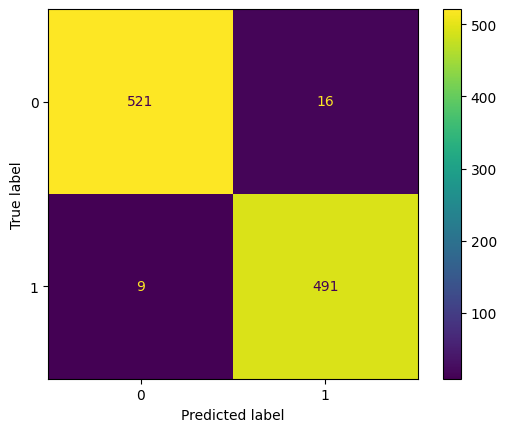

In [23]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

# CM
cm = confusion_matrix(mal_test, predicted)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

# Accuracy and performance
accuracy = accuracy_score(predicted, mal_test)
precision = precision_score(mal_test, predicted)
recall = recall_score(mal_test, predicted)
f1 = f1_score(predicted, mal_test, average="weighted")

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1)